# 1. Setup e carregamento dos dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
df = pd.read_excel('Case_Vendas.xlsx')
df.head()

,Mês,Categoria,Custo Entrega,Custo dos Produtos,Custo Marketing
0,1,AC AUDIO,80353.50458,36247.578746,11352.354514
1,1,AC BT SPEAKER,45448.46538,82168.278219,19423.724235
2,1,AC CALCULADORA,2253.74290,3309.124869,813.303043
3,1,AC CELULARES,22829.13170,18308.656441,5471.035672
4,1,AC ELETRODOMESTICO,432.07736,76.286501,33.111653


# 2. Análise Exploratória (EDA)

In [4]:
print('Shape:', df.shape)
print('\nTipos de dados:')
print(df.dtypes)
print('\nValores nulos:')
print(df.isnull().sum())

Shape: (3521, 5)

Tipos de dados:
Mês                     int64
Categoria              object
Custo Entrega         float64
Custo dos Produtos    float64
Custo Marketing       float64
dtype: object

Valores nulos:
Mês                   0
Categoria             0
Custo Entrega         0
Custo dos Produtos    0
Custo Marketing       0
dtype: int64


In [5]:
print('Meses disponíveis:', sorted(df['Mês'].unique()))
print('Categorias únicas:', df['Categoria'].nunique())
print()
df.describe()

Meses disponíveis: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Categorias únicas: 415



,Mês,Custo Entrega,Custo dos Produtos,Custo Marketing
count,3521.000000,3.521000e+03,3.521000e+03,3.521000e+03
mean,4.980403,3.031283e+05,1.361742e+06,2.920965e+05
std,2.582263,3.108082e+06,1.461941e+07,2.959444e+06
min,1.000000,0.000000e+00,2.331519e-01,6.816765e-02
25%,3.000000,4.387751e+03,1.631838e+03,4.735437e+02
50%,5.000000,2.984134e+04,1.412240e+04,3.866200e+03
75%,7.000000,1.449348e+05,9.337045e+04,2.539583e+04
max,9.000000,1.579374e+08,4.170808e+08,9.791486e+07


# 3. Análise de Tendência Mensal

In [6]:
df_mensal = df.groupby('Mês')[['Custo Entrega', 'Custo dos Produtos', 'Custo Marketing']].sum().reset_index()
df_mensal

,Mês,Custo Entrega,Custo dos Produtos,Custo Marketing
0,1,6.208080e+07,5.242774e+08,1.405367e+08
1,2,6.066497e+07,5.201803e+08,1.474489e+08
2,3,7.654509e+07,5.359895e+08,1.374846e+08
3,4,9.106978e+07,5.334520e+08,1.328424e+08
4,5,1.023234e+08,5.535901e+08,1.044378e+08
5,6,1.234420e+08,5.410871e+08,9.614168e+07
6,7,1.595527e+08,5.186694e+08,9.222941e+07
7,8,1.758698e+08,5.475613e+08,9.386450e+07
8,9,2.157664e+08,5.198852e+08,8.348574e+07


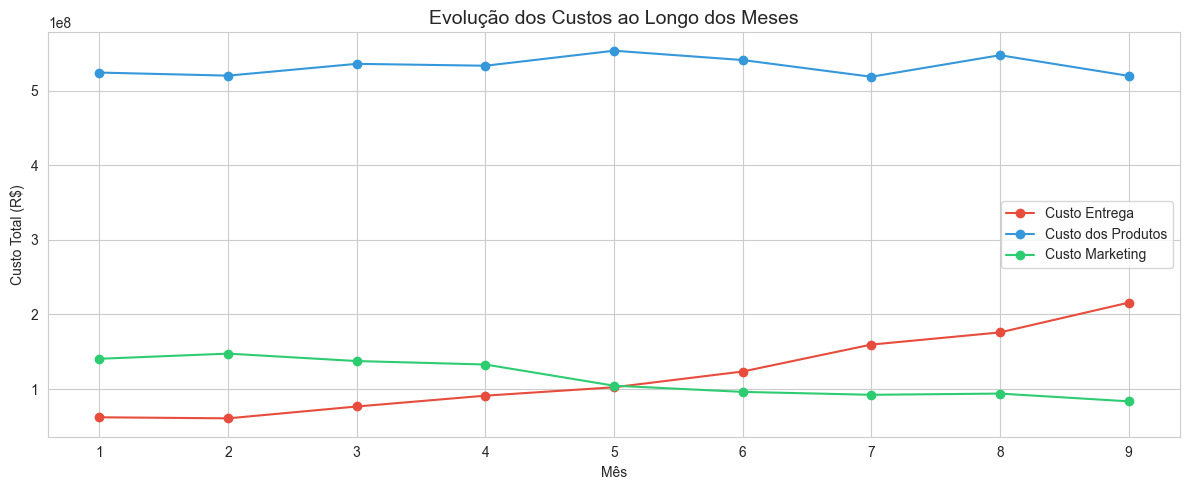

In [7]:
fig, ax = plt.subplots()
ax.plot(df_mensal['Mês'], df_mensal['Custo Entrega'],     marker='o', label='Custo Entrega',     color='#E74C3C')
ax.plot(df_mensal['Mês'], df_mensal['Custo dos Produtos'], marker='o', label='Custo dos Produtos', color='#3498DB')
ax.plot(df_mensal['Mês'], df_mensal['Custo Marketing'],   marker='o', label='Custo Marketing',   color='#2ECC71')
ax.set_title('Evolução dos Custos ao Longo dos Meses', fontsize=14)
ax.set_xlabel('Mês')
ax.set_ylabel('Custo Total (R$)')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Calculando a variação percentual entre mês 1 e mês 9
mes1 = df_mensal[df_mensal['Mês'] == 1][['Custo Entrega', 'Custo dos Produtos', 'Custo Marketing']].values[0]
mes9 = df_mensal[df_mensal['Mês'] == 9][['Custo Entrega', 'Custo dos Produtos', 'Custo Marketing']].values[0]

variacao = ((mes9 - mes1) / mes1) * 100

for col, var in zip(['Custo Entrega', 'Custo dos Produtos', 'Custo Marketing'], variacao):
    print(f'{col}: {var:+.1f}%')

Custo Entrega: +247.6%
Custo dos Produtos: -0.8%
Custo Marketing: -40.6%


O gráfico deixa evidente: o custo de entrega sobe consistentemente mês a mês — de ~62M no mês 1 para ~215M no mês 9, um aumento de quase 250%. O custo de produto oscila mas se mantém estável, e o custo de marketing cai levemente. Isso confirma minha hipótese: o custo de entrega é o principal driver da queda de rentabilidade

# 4. Análise de Correlação

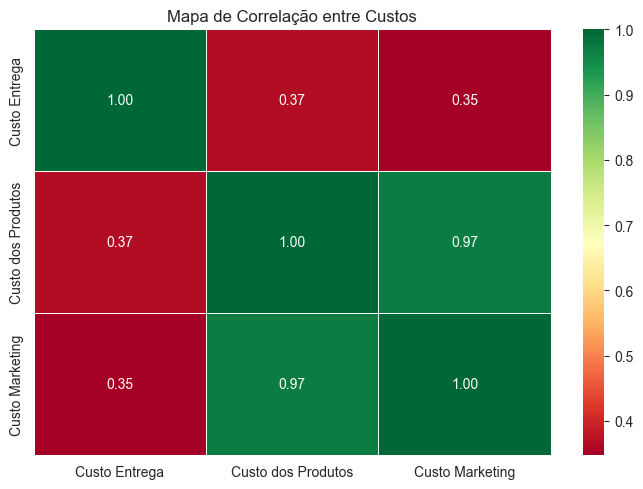

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
correlacao = df[['Custo Entrega', 'Custo dos Produtos', 'Custo Marketing']].corr()
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, linewidths=0.5)
ax.set_title('Mapa de Correlação entre Custos')
plt.tight_layout()
plt.show()

Há correlação moderada entre custo de entrega e custo de produto (0.4) e entre entrega e marketing (0.3). Isso faz sentido: produtos mais caros tendem a ter maior volumetria ou maior valor agregado, o que encarece o frete. Vou investigar quais categorias têm os maiores custos de entrega

C:\Users\julli\AppData\Local\Temp\ipykernel_9676\209911837.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cat, x='Custo Entrega', y='Categoria', palette='Reds_r', ax=ax)


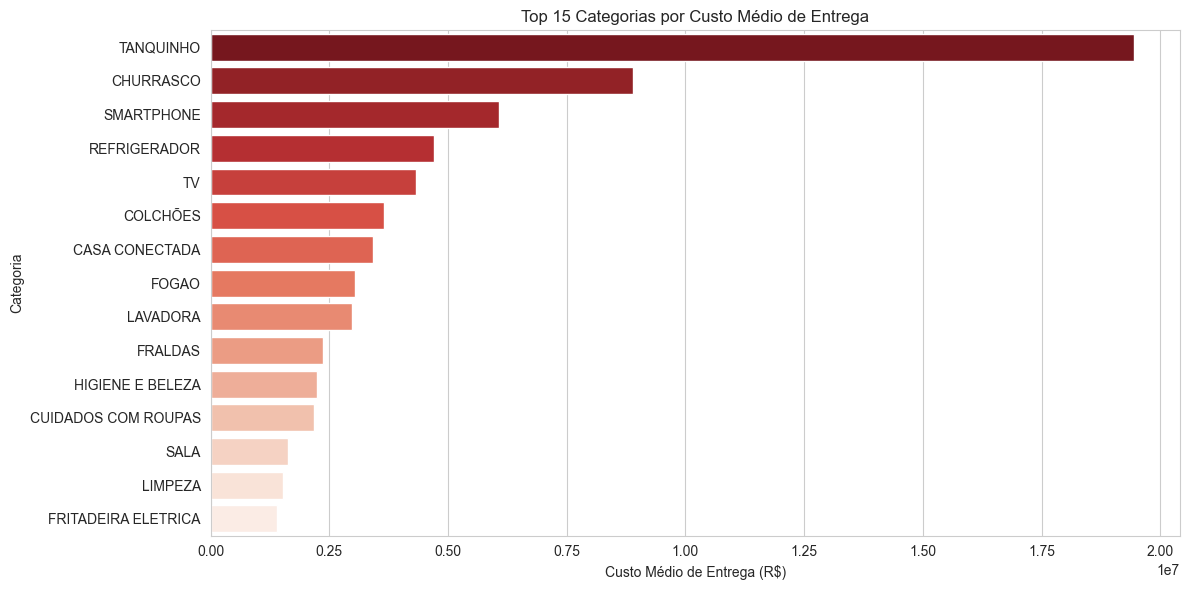

In [10]:
# Top 15 categorias com maior custo médio de entrega
df_cat = df.groupby('Categoria')[['Custo Entrega', 'Custo dos Produtos', 'Custo Marketing']].mean()
df_cat = df_cat.sort_values('Custo Entrega', ascending=False).head(15).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_cat, x='Custo Entrega', y='Categoria', palette='Reds_r', ax=ax)
ax.set_title('Top 15 Categorias por Custo Médio de Entrega')
ax.set_xlabel('Custo Médio de Entrega (R$)')
plt.tight_layout()
plt.show()

# 5. Modelagem

Neste tópico treino um modelo para prever o custo de entrega por categoria e mês. A questão é: se conseguimos prever o custo de entrega com antecedência, podemos agir proativamente (renegociar contratos ou ajustar preços dos produtos, por exemplo).

Minha target é o Custo de Entrega. As features são: mês, categoria encodada, custo de produto e custo de marketing. Vou usar LabelEncoder para transformar a categoria em número.

In [11]:
le = LabelEncoder()
df['Categoria_enc'] = le.fit_transform(df['Categoria'])

X = df[['Mês', 'Categoria_enc', 'Custo dos Produtos', 'Custo Marketing']]
y = df['Custo Entrega']

print('Features:', X.columns.tolist())
print('Shape X:', X.shape)
print('Target — Custo de Entrega')

Features: ['Mês', 'Categoria_enc', 'Custo dos Produtos', 'Custo Marketing']
Shape X: (3521, 4)
Target — Custo de Entrega


Vou testar 3 modelos: Regressão Linear como baseline simples, Random Forest e Gradient Boosting. Uso cross-validation com 5 folds para ter uma estimativa mais robusta.

In [12]:
modelos = {
    'Linear Regression (baseline)': LinearRegression(),
    'Random Forest':                 RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':             GradientBoostingRegressor(n_estimators=100, random_state=42)
}

resultados = []
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X, y, cv=5, scoring='neg_mean_absolute_error')
    resultados.append({'Modelo': nome, 'MAE Médio': -scores.mean(), 'Desvio Padrão': scores.std()})

df_resultados = pd.DataFrame(resultados).sort_values('MAE Médio')
df_resultados

,Modelo,MAE Médio,Desvio Padrão
2,Gradient Boosting,286745.308164,149399.000196
1,Random Forest,292605.939696,144706.745054
0,Linear Regression (baseline),522264.021394,200468.686837


Agora faço o split tradicional 80/20 para avaliar as métricas no conjunto de teste — dados que o modelo nunca viu. Vou reportar MAE, RMSE e R²

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_final = GradientBoostingRegressor(n_estimators=100, random_state=42)
modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE:  R$ {mae:,.0f}')
print(f'RMSE: R$ {rmse:,.0f}')
print(f'R²:   {r2:.3f}')

MAE:  R$ 177,515
RMSE: R$ 694,796
R²:   0.396


Para melhorar essa análise seria ideal ter mais dados: informações de peso/volume dos produtos, CEP de destino, transportadora utilizada etc. mas considerando apenas os dados desse case, é possível identificar os principais preditores. Uso feature importance para entender quais variáveis o modelo considerou mais relevantes.

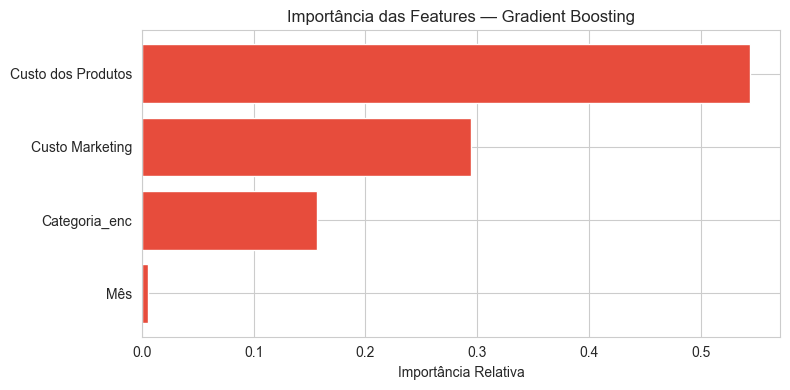

In [14]:
importancias = pd.DataFrame({
    'Feature':    X.columns,
    'Importância': modelo_final.feature_importances_
}).sort_values('Importância', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importancias['Feature'], importancias['Importância'], color='#E74C3C')
ax.set_title('Importância das Features — Gradient Boosting')
ax.set_xlabel('Importância Relativa')
plt.tight_layout()
plt.show()

O Custo dos Produtos é a feature mais importante (54%), seguido de Custo de Marketing (29%) e Categoria (16%). O Mês em si tem pouca importância isolado — o que confirma que a tendência de crescimento não é capturada só pelo número do mês, mas pela interação com categoria e custo de produto. Em termos de negócio: quanto mais caro o produto, mais caro o frete — reforçando a análise exploratória.

# Conclusões

- Correlação moderada com custo de produto (0.4): produtos mais caros/volumosos têm frete mais caro
- As categorias com maior custo de entrega são eletrodomésticos, móveis e TVs — produtos de alta volumetria
- Fatores externos prováveis: aumento de combustível, mudança de transportadora, expansão geográfica
- Gradient Boosting com R² = 0.40 — o custo de produto é o maior preditor do custo de entrega


**Recomendações:**
1. Investigar o contrato logístico 
2. Enriquecer o modelo com mais dados melhorar a predição
3. Monitorar o custo_entrega como KPI de alerta